# Importing Libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

# Test set Image Processing

In [2]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

# Loading Model

In [3]:
cnn = tf.keras.models.load_model('trained_plant_disease_model.keras')

In [4]:
import sys
print(sys.executable)

C:\Users\hp\anaconda3\python.exe


#Visualising and Performing Prediction on Single image

In [11]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


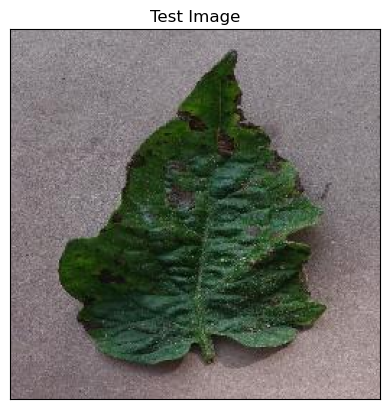

In [14]:
#Test Image Visualization
import cv2
image_path = 'test/test/TomatoEarlyBlight3.JPG'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

## Testing Model

In [15]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


In [16]:
print(predictions)

[[1.0080434e-05 6.5310551e-06 5.7816687e-05 4.3205596e-03 2.8079290e-05
  8.2430306e-06 1.4815242e-07 8.6126562e-07 2.2176108e-08 6.1668226e-07
  1.7716937e-07 9.4882904e-05 4.1512569e-04 9.3242370e-06 6.9926472e-08
  4.1472627e-05 2.8050597e-05 1.2868269e-05 1.4048116e-05 6.5384215e-06
  7.0499357e-07 1.3965742e-04 1.7354747e-04 2.7424359e-05 5.2687515e-06
  6.0326147e-07 1.8743125e-05 1.0472364e-06 4.7372194e-04 4.8590475e-01
  9.5841679e-04 1.6384587e-02 3.1628273e-04 4.0342197e-01 1.8693227e-02
  1.3130708e-02 5.5204850e-02 8.8985274e-05]]


In [17]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

29


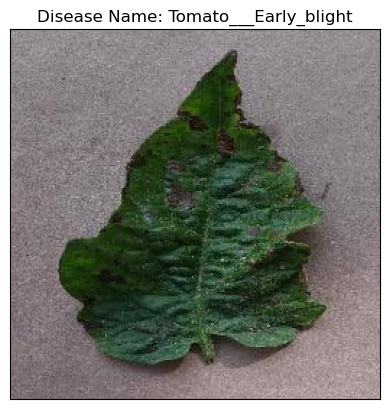

In [18]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [13]:
cnn.save("trained_plant_disease_model_fixed.keras")